### 1. Initialise SparkSession
##### ✅ Always required.

In [ ]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("ML Workflow").getOrCreate()

### 2. Load Data
##### ✅ Always required. Use `inferSchema=True` or define schema manually.

In [ ]:
df = spark.read.csv("data.csv", header=True, inferSchema=True)

### 3. Handle Missing/Null Values
##### ✅ Needed when your data contains nulls (very common).
##### ❌ Skip if dataset is guaranteed clean.

In [ ]:
df = df.dropna()  # or
df = df.fillna({'age': 30, 'income': 0})

### 4. Data Type Casting
##### ✅ Required when numeric columns are read as strings (e.g., from CSV).
##### ❌ Not needed if Spark inferred correct types.

In [ ]:
from pyspark.sql.functions import col
df = df.withColumn("age", col("age").cast("double"))

### 5. Encode Categorical Columns
##### ✅ Needed if your dataset has string columns for categories (e.g., "Male", "Female").
##### ❌ Not needed if all features are numeric or already encoded.

In [ ]:
from pyspark.ml.feature import StringIndexer

indexer = StringIndexer(inputCol="gender", outputCol="gender_indexed")
df = indexer.fit(df).transform(df)

### Use `OneHotEncoder` if needed after `StringIndexer` for linear models
#### Can it be used directly on `categorical` data?
###### ❌ No, you cannot directly use `OneHotEncoder` on raw string columns in PySpark.
###### ✅ You must use `StringIndexer` first.
###### PySpark’s OneHotEncoder only accepts numerical indices as input — not strings.

In [ ]:
from pyspark.ml.feature import OneHotEncoder
encoder = OneHotEncoder(inputCols=["gender_indexed"], outputCols=["gender_vec"])
df = encoder.fit(df).transform(df)

### 6. Assemble Features
##### ✅ Always needed before applying Spark ML models. Takes multiple feature columns and merges them into a single vector.

In [ ]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["age", "income", "gender_vec"],  # Use indexed columns
    outputCol="features"
)
df = assembler.transform(df)

### 7. VectorIndexer (Optional but Important for Tree Models)
##### ✅ Needed for tree-based models if your assembled features include categorical numeric values.
##### ❌ Not needed for linear models, or if you’ve already applied `StringIndexer`.

In [ ]:
from pyspark.ml.feature import VectorIndexer

indexer = VectorIndexer(inputCol="features", outputCol="indexedFeatures", maxCategories=10)
df = indexer.fit(df).transform(df)

#### Use `"indexedFeatures"` in your model if you apply this step.

### 8. Sparse to Dense Vector Representation
| Situation                    | Convert to Dense?             |
| ---------------------------- | ----------------------------- |
| Using `StandardScaler`       | ⚠️ Sometimes (to be safe)     |
| Using `MinMaxScaler`         | ✅ Recommended if errors occur |
| Using tree-based models      | ❌ No need (trees don't care)  |
| Doing custom transformations | ✅ Often safer to use dense    |
| High-dimensional sparse data | ❌ Avoid dense (memory-heavy)  |


In [ ]:
from pyspark.sql.functions import udf
from pyspark.ml.linalg import Vectors, VectorUDT
import pyspark.sql.functions as F

sparseToDense = F.udf(lambda v : Vectors.dense(v), VectorUDT())
df_assembled_dense = df_assembled.withColumn('features_array', sparseToDense('features'))

In [ ]:
from pyspark.sql.functions import udf
from pyspark.ml.linalg import Vectors, VectorUDT
import pyspark.sql.functions as F

sparseToDense = F.udf(lambda v : Vectors.dense(v), VectorUDT())
df_assembled_dense = df_assembled.withColumn('features_array', sparseToDense('features'))

### 9. Feature Scaling (Optional)
##### ✅ Recommended for linear models, distance-based models, or when features have very different scales.
##### ❌ Often not needed for tree-based models like `RandomForest`, `GBT`, etc.

#### Standard Scaler

In [ ]:
from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(inputCol="features_array", outputCol="scaledFeatures")
df = scaler.fit(df).transform(df)

#### MinMaxScaler

In [ ]:
from pyspark.ml.feature import MinMaxScaler

scaler = MinMaxScaler(inputCol="features_array", outputCol="scaledFeatures")
# You can customize the output range using MinMaxScaler.setMin() and setMax(), but [0, 1] is standard.
# scaler = scaler.setMin(-1).setMax(1)
df = scaler.fit(df).transform(df)

In [ ]:
from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures")
df = scaler.fit(df).transform(df)

#### Use `"scaledFeatures"` in your model if you apply this step.

### 10. Split the Data
##### ✅ Always needed before training/evaluation.

In [ ]:
train_data, test_data = df.randomSplit([0.8, 0.2], seed=0)

### 11. Model Training
##### Choose based on the problem type:

#### Regression:

In [ ]:
from pyspark.ml.regression import LinearRegression
model = LinearRegression(featuresCol="scaledFeatures", labelCol="target").fit(train_data)

#### Classification:
##### For tree models, use `"features"` or `"indexedFeatures"` as appropriate.

In [ ]:
from pyspark.ml.classification import LogisticRegression
model = LogisticRegression(featuresCol="scaledFeatures", labelCol="target").fit(train_data)

### 12. Make Predictions

In [ ]:
predictions = model.transform(test_data)

### 13. Model Evaluation
##### Use appropriate evaluator based on task:

#### Regression:

In [ ]:
from pyspark.ml.evaluation import RegressionEvaluator
evaluator = RegressionEvaluator(labelCol="target", predictionCol="prediction", metricName="rmse")
rmse = evaluator.evaluate(predictions)

#### Classification:

In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
evaluator = BinaryClassificationEvaluator(labelCol="target")
auc = evaluator.evaluate(predictions)

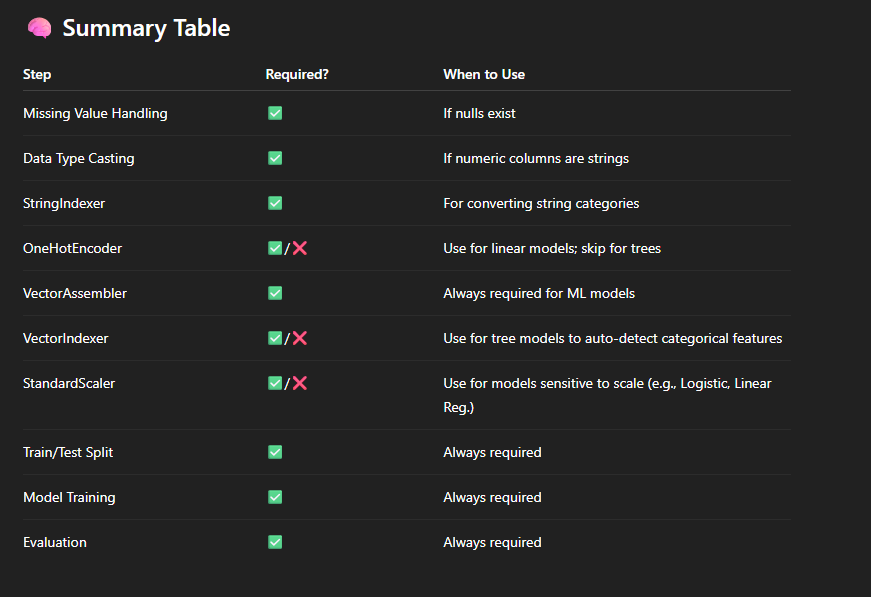